In [56]:
import numpy as np
import os
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torchvision import transforms
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [57]:
def preprocess(image_tensor):

    eps = 1e-8
    I = image_tensor + eps

    I_max = I.max()
    log_contrast = (torch.log(I_max/I))**2

    grad_y = torch.gradient(log_contrast, dim=-2)[0]  # height dimension
    grad_xy = torch.gradient(grad_y, dim=-1)[0]        # width dimension

    preprocessed = torch.abs(torch.tanh(grad_xy))

    return preprocessed

In [58]:
class LensDataset(Dataset):

    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.paths = []
        self.labels = []

        # find classes
        self.classes = sorted([
            d for d in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, d))
        ])

        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        # collect files
        for cls in self.classes:
            cls_folder = os.path.join(root_dir, cls)

            for file in os.listdir(cls_folder):
                if file.endswith(".npy"):
                    self.paths.append(os.path.join(cls_folder, file))
                    self.labels.append(self.class_to_idx[cls])

    def __len__(self):
        return len(self.paths)
    
    def physics_preprocess(self, img):
        """Full LensPINN transform - channel 1"""
        eps = 1e-8
        I = img + eps
        I_max = I.max()
        log_contrast = (torch.log(I_max / I)) ** 2
        grad_y = torch.gradient(log_contrast, dim=-2)[0]
        grad_xy = torch.gradient(grad_y, dim=-1)[0]
        preprocessed = torch.abs(torch.tanh(grad_xy))
        return preprocessed
    
    def log_contrast(self, img):
        """Intermediate log contrast step - channel 2"""
        eps = 1e-8
        I = img + eps
        I_max = I.max()
        enhanced = (torch.log(I_max / I)) ** 2
        # normalize to [0,1]
        enhanced = (enhanced - enhanced.min()) / \
                   (enhanced.max() - enhanced.min() + eps)
        return enhanced
    
    def laplacian_channel(self, img):
        """
        Isotropic second-order edge detector.
        Physically motivated: detects localized mass concentrations
        (subhalo substructure) as blob-like intensity perturbations.
        Ref: Marr & Hildreth (1980)
        """
        eps = 1e-8
        I = img + eps
        
        # second derivatives
        grad_x = torch.gradient(I, dim=-1)[0]
        grad_xx = torch.gradient(grad_x, dim=-1)[0]
        
        grad_y = torch.gradient(I, dim=-2)[0]
        grad_yy = torch.gradient(grad_y, dim=-2)[0]
        
        laplacian = grad_xx + grad_yy
        laplacian = torch.abs(torch.tanh(laplacian))
        return laplacian

    def __getitem__(self, idx):
        image = np.load(self.paths[idx])
        image = torch.tensor(image, dtype=torch.float32)
        
        if image.ndim == 2:
            image = image.unsqueeze(0)          # (1, 150, 150)
        
        ch0 = image                              # raw
        ch1 = self.physics_preprocess(image)     # LensPINN edge map
        ch2 = self.laplacian_channel(image)           # log contrast
        
        combined = torch.cat([ch0, ch1, ch2], dim=0)  # (3, 150, 150)
        
        if self.transform:
            combined = self.transform(combined)
        
        return combined, self.labels[idx]

In [59]:
train_dataset_no_norm = LensDataset(
    "dataset/train"
)
image, label = train_dataset_no_norm[0]

print(image.shape)
print(label)

torch.Size([3, 150, 150])
0


In [68]:
def compute_channel_stats(dataset):
    """
    Compute per-channel mean and std across the training set.
    Works for any number of channels.
    """
    # peek at first sample to get number of channels dynamically
    sample_img, _ = dataset[0]
    n_channels = sample_img.shape[0]
    
    sum_ch = torch.zeros(n_channels)
    sum_sq_ch = torch.zeros(n_channels)
    count = 0
    
    temp_loader = DataLoader(dataset, batch_size=64, 
                             shuffle=False, num_workers=4)
    
    for images, _ in temp_loader:
        # images shape: (B, C, H, W)
        sum_ch += images.sum(dim=[0, 2, 3])
        sum_sq_ch += (images ** 2).sum(dim=[0, 2, 3])
        count += images.shape[0] * images.shape[2] * images.shape[3]
    
    mean = sum_ch / count
    std = torch.sqrt(sum_sq_ch / count - mean ** 2)
    
    return mean.tolist(), std.tolist()
mean,std = compute_channel_stats(train_dataset_no_norm)
print(mean)
print(std)

[0.061692770570516586, 0.5237485766410828, 0.006890553515404463]
[0.1172683984041214, 0.3460021913051605, 0.0099486093968153]


Ch 0 range: 0.0 to 1.0
Ch 1 range: 0.0 to 1.0
Ch 2 range: 0.0 to 0.16266630589962006
Ch 2 nonzero fraction: 0.18297778069972992


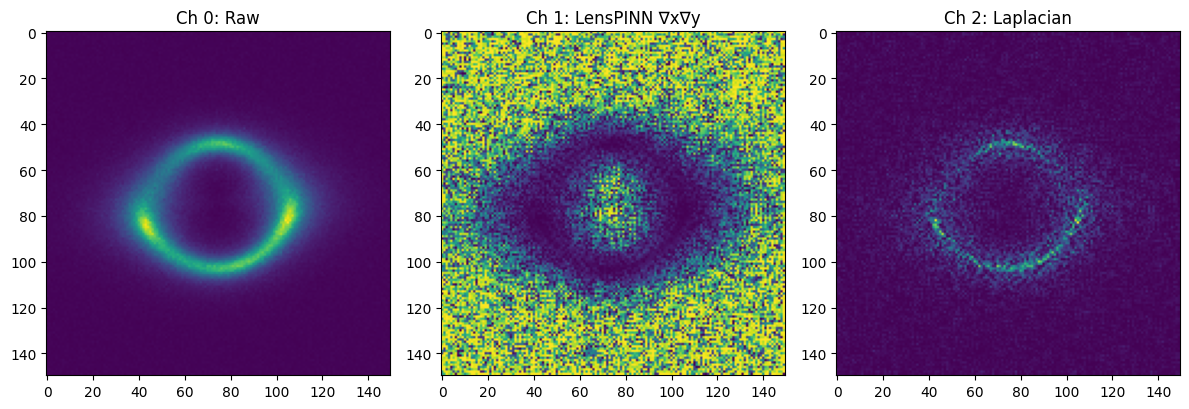

In [69]:
# Load one sample and inspect all 3 channels
dataset_check = LensDataset("dataset/train", transform=None)
img, label = dataset_check[0]

print("Ch 0 range:", img[0].min().item(), "to", img[0].max().item())
print("Ch 1 range:", img[1].min().item(), "to", img[1].max().item())
print("Ch 2 range:", img[2].min().item(), "to", img[2].max().item())

print("Ch 2 nonzero fraction:", 
      (img[2] > 0.01).float().mean().item())

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img[0].numpy(), cmap='viridis')
axes[0].set_title("Ch 0: Raw")
axes[1].imshow(img[1].numpy(), cmap='viridis')
axes[1].set_title("Ch 1: LensPINN ∇x∇y")
axes[2].imshow(img[2].numpy(), cmap='viridis')
axes[2].set_title("Ch 2: Laplacian")
plt.tight_layout()
plt.show()

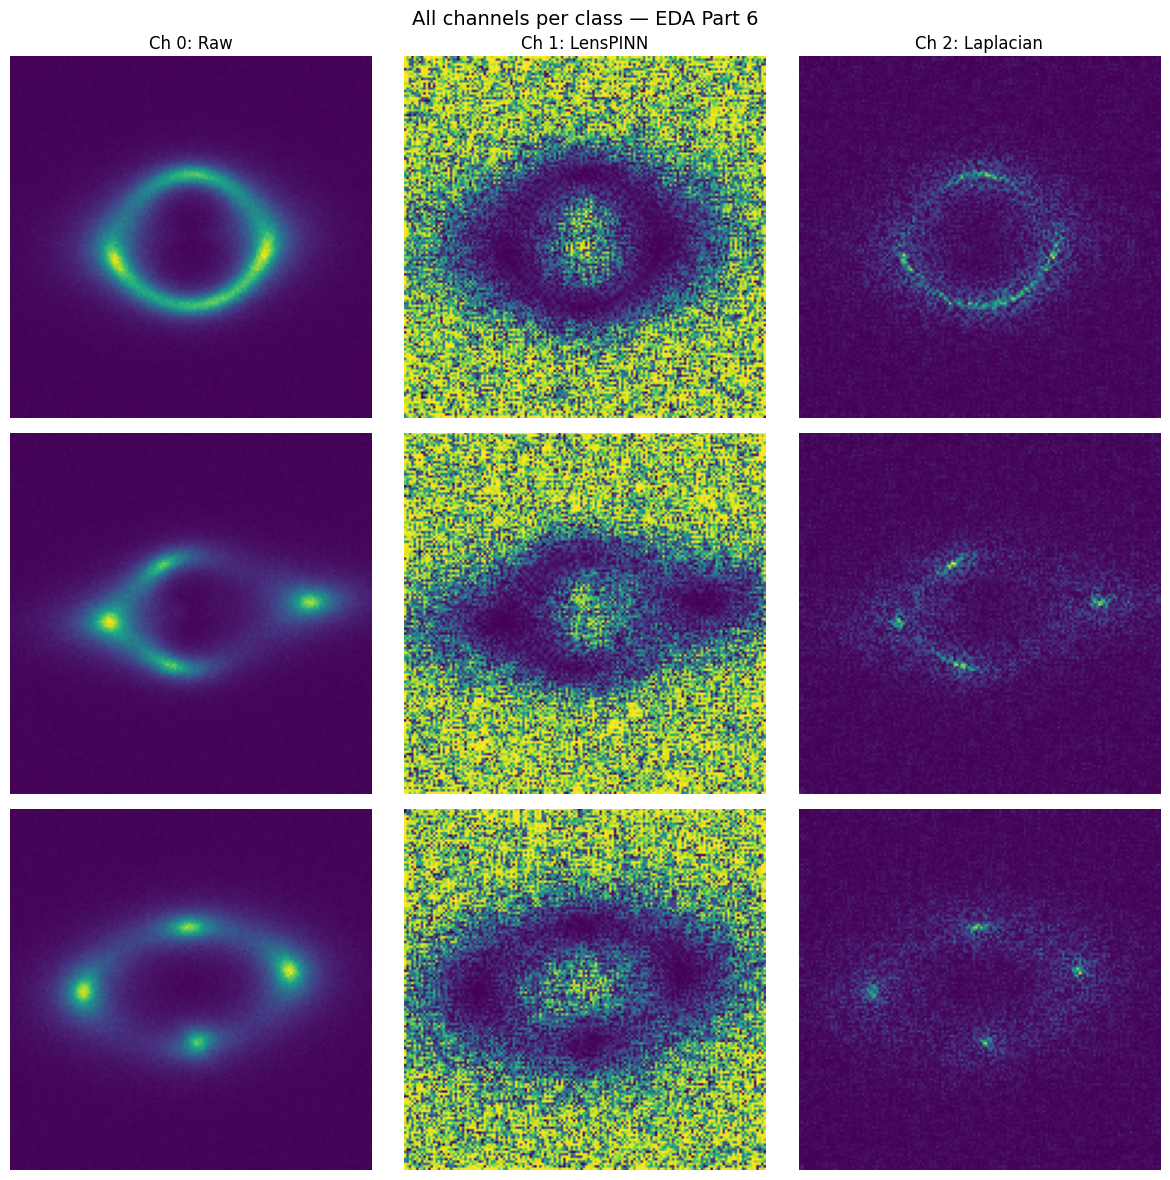

In [76]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
class_names = ['no_sub', 'subhalo', 'vortex']

for class_idx in range(3):
    # find first sample of this class
    sample_idx = dataset_check.labels.index(class_idx)
    img, _ = dataset_check[sample_idx]
    
    for ch in range(3):
        axes[class_idx][ch].imshow(img[ch].numpy(), cmap='viridis')
        axes[class_idx][ch].axis('off')
        
axes[0][0].set_title("Ch 0: Raw")
axes[0][1].set_title("Ch 1: LensPINN")
axes[0][2].set_title("Ch 2: Laplacian")

for i, name in enumerate(class_names):
    axes[i][0].set_ylabel(name, fontsize=12)

plt.suptitle("All channels per class — EDA Part 6", fontsize=14)
plt.tight_layout()
plt.savefig("all_channels_no_initial.png")
plt.show()

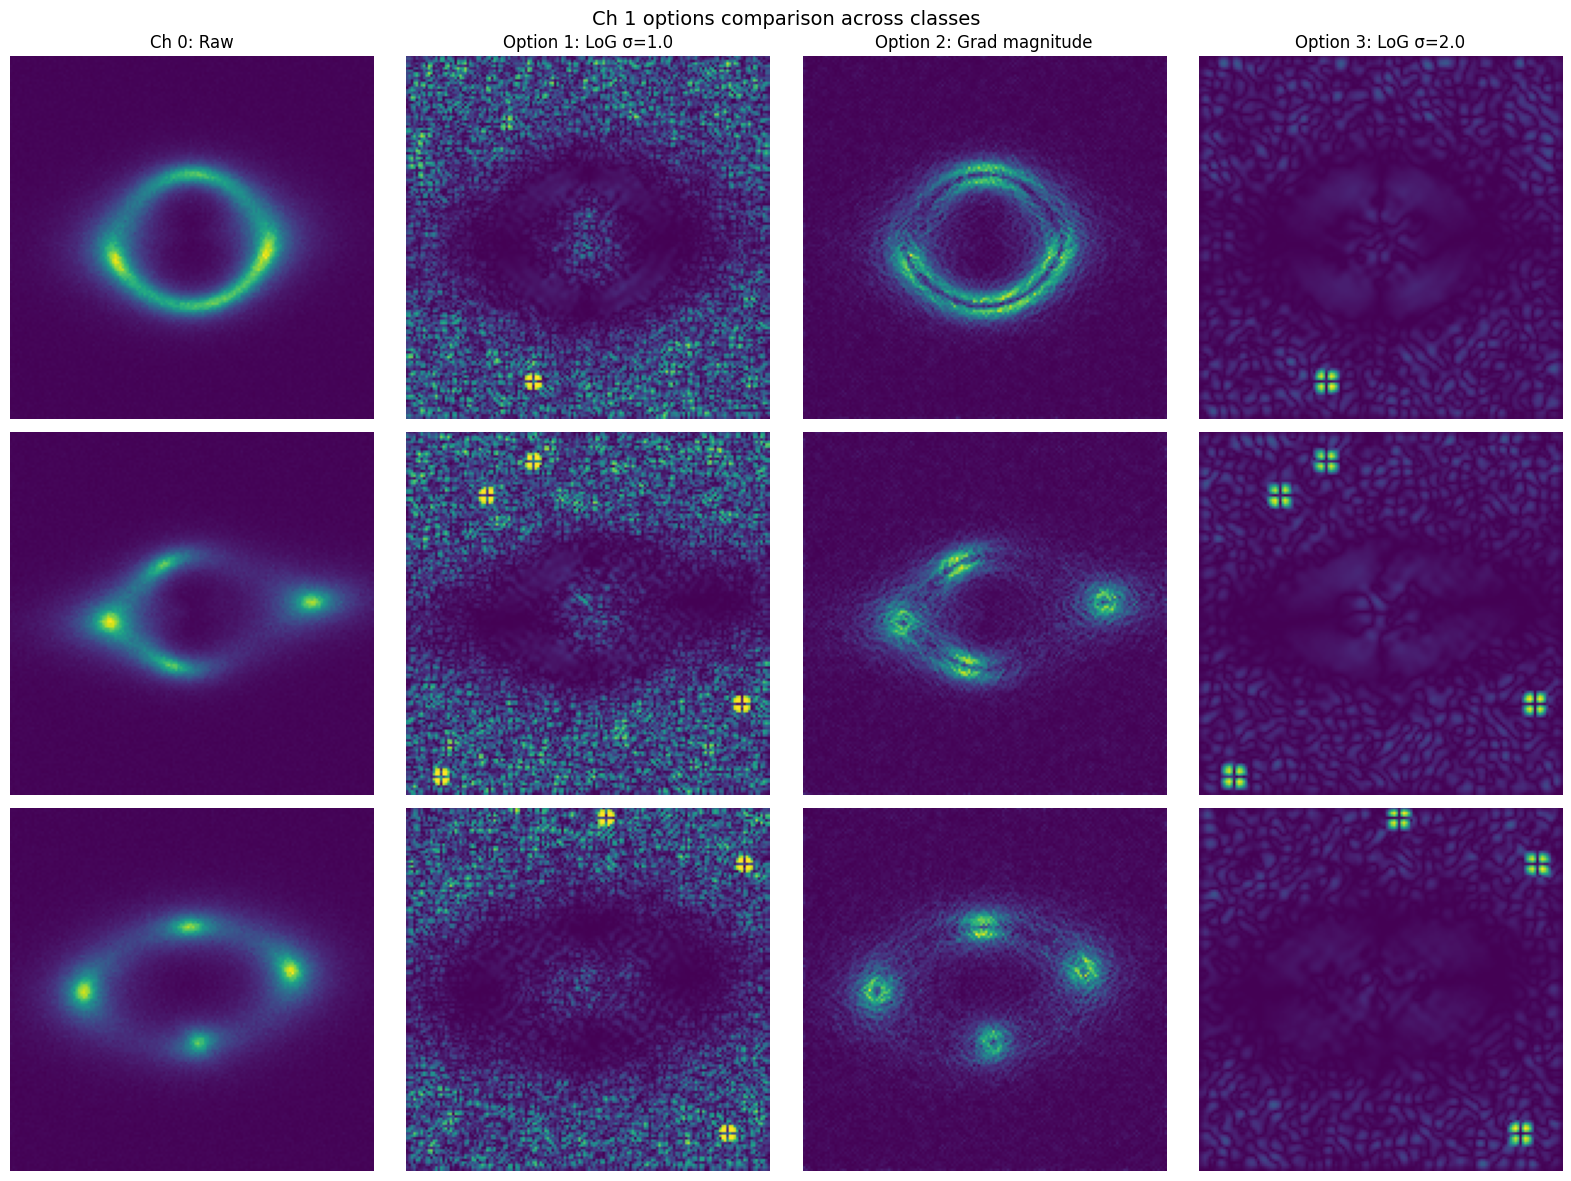

In [75]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
class_names = ['no_sub', 'subhalo', 'vortex']

def ch1_option1(img, sigma=1.0):
    """LensPINN with mild Gaussian"""
    eps = 1e-8
    I = img + eps
    smoothed = transforms.functional.gaussian_blur(
        (torch.log(I.max()/I))**2, kernel_size=5, sigma=sigma)
    gy = torch.gradient(smoothed, dim=-2)[0]
    gxy = torch.gradient(gy, dim=-1)[0]
    return torch.abs(torch.tanh(gxy))

def ch1_option2(img):
    """Gradient magnitude — more stable"""
    eps = 1e-8
    I = img + eps
    gx = torch.gradient(I, dim=-1)[0]
    gy = torch.gradient(I, dim=-2)[0]
    mag = torch.sqrt(gx**2 + gy**2 + eps)
    return (mag - mag.min()) / (mag.max() - mag.min() + eps)

def ch1_option3(img, sigma=2.0):
    """LensPINN with stronger Gaussian"""
    eps = 1e-8
    I = img + eps
    smoothed = transforms.functional.gaussian_blur(
        (torch.log(I.max()/I))**2, kernel_size=9, sigma=sigma)
    gy = torch.gradient(smoothed, dim=-2)[0]
    gxy = torch.gradient(gy, dim=-1)[0]
    return torch.abs(torch.tanh(gxy))

for class_idx in range(3):
    sample_idx = dataset_check.labels.index(class_idx)
    img, _ = dataset_check[sample_idx]
    raw = img[0:1]  # original single channel
    
    axes[class_idx][0].imshow(raw[0].numpy(), cmap='viridis')
    axes[class_idx][0].set_title("Ch 0: Raw") if class_idx==0 else None
    
    axes[class_idx][1].imshow(ch1_option1(raw)[0].numpy(), cmap='viridis')
    axes[class_idx][1].set_title("Option 1: LoG σ=1.0") if class_idx==0 else None
    
    axes[class_idx][2].imshow(ch1_option2(raw)[0].numpy(), cmap='viridis')
    axes[class_idx][2].set_title("Option 2: Grad magnitude") if class_idx==0 else None
    
    axes[class_idx][3].imshow(ch1_option3(raw)[0].numpy(), cmap='viridis')
    axes[class_idx][3].set_title("Option 3: LoG σ=2.0") if class_idx==0 else None
    
    for ax in axes[class_idx]:
        ax.axis('off')
    axes[class_idx][0].set_ylabel(class_names[class_idx], fontsize=11)

plt.suptitle("Ch 1 options comparison across classes", fontsize=14)
plt.tight_layout()
plt.savefig("eda_ch1_options_comparison.png")

plt.show()

In [ ]:
# Your computed stats
MEAN = [0.0617, 0.5237, 0.0069]
STD  = [0.1173, 0.3460, 0.0099]

# But Ch 2 std is dangerously small
# Add a minimum std floor to prevent exploding normalized values
MIN_STD = 0.05
STD = [max(s, MIN_STD) for s in STD]
# STD becomes: [0.1173, 0.3460, 0.0500]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.Normalize(mean=MEAN, std=STD)
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=MEAN, std=STD)
])

In [62]:
train_dataset = LensDataset(
    "dataset/train",
    transform=train_transform
)

val_dataset = LensDataset(
    "dataset/val",
    transform=val_transform
)

In [63]:

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, 
                        num_workers=4, pin_memory=True)

In [64]:
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 938
Val batches: 235


In [65]:
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch labels:", labels)

Batch image shape: torch.Size([32, 3, 224, 224])
Batch labels: tensor([2, 2, 0, 1, 0, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 0, 2, 1,
        2, 1, 1, 0, 2, 2, 1, 1])


In [66]:
from collections import Counter

train_counts = Counter(train_dataset.labels)
val_counts = Counter(val_dataset.labels)

print("Train distribution:", train_counts)
print("Val distribution:", val_counts)

Train distribution: Counter({0: 10000, 1: 10000, 2: 10000})
Val distribution: Counter({0: 2500, 1: 2500, 2: 2500})


In [67]:
def preprocess(image_tensor):

    eps = 1e-8
    I = image_tensor + eps

    I_max = I.max()
    log_contrast = (torch.log(I_max/I))**2

    grad_y = torch.gradient(log_contrast, dim=-2)[0]  # height dimension
    grad_xy = torch.gradient(grad_y, dim=-1)[0]        # width dimension

    preprocessed = torch.abs(torch.tanh(grad_xy))

    return preprocessed